In [26]:
# ===================================================================
# CELDA 1: INSTALACIÓN DE LIBRERÍAS
# ===================================================================
# NFStream es la librería clave para analizar los archivos .pcap
# El resto son para manipulación de datos, IA y gráficos.
# El -q es para que la salida de la instalación sea más limpia (quiet).
# ===================================================================
!pip install -q nfstream pandas numpy scikit-learn matplotlib seaborn


In [27]:
# ===================================================================
# CELDA 2: IMPORTACIÓN DE MÓDULOS
# ===================================================================
import os
import pandas as pd
import numpy as np
import re
from datetime import datetime
from nfstream import NFStreamer
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
import warnings
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PATH_DRIVE = '/content/drive/MyDrive'
# Ignoramos advertencias para mantener la salida limpia
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")


Mounted at /content/drive
Librerías importadas correctamente.


In [28]:
# ===================================================================
# CELDA 3: FUNCIÓN INTELIGENTE DE DESFASE
# ===================================================================
def obtener_desfase_por_csv(archivo_sync, archivo_csv):
    """
    Calcula el desfase temporal entre el timestamp del juego y el timestamp UNIX
    buscando una marca de sincronización en un archivo de log.
    """
    print(f"   -> Buscando sincronización para {archivo_csv}...")
    
    # Extrae la fecha y hora del nombre del fichero de telemetría (ej: YYYYMMDD_HHMMSS)
    match_csv = re.search(r"(\d{8}_\d{6})", archivo_csv)
    if not match_csv:
        raise ValueError("El nombre del CSV no tiene el formato de fecha esperado (YYYYMMDD_HHMMSS).")
    fecha_csv = match_csv.group(1)
    
    with open(archivo_sync, 'r') as f:
        for linea in f: # Buscar linea por linea en el archivo de sincronización
            patron = r"\[([\d\.]+)\] ==== \[SYNC_TELEMETRIA\] Tiempo interno: ([\d\.]+) ===="
            match = re.search(patron, linea) # Extrae el tiempo UNIX y el tiempo del juego
            if match:
                tiempo_unix = float(match.group(1))
                tiempo_juego_sec = float(match.group(2))
                
                # Compara si la fecha y hora del log coincide con la del archivo CSV
                fecha_unix_str = datetime.fromtimestamp(tiempo_unix).strftime("%Y%m%d_%H%M%S")
                if fecha_unix_str == fecha_csv:
                    desfase = tiempo_unix - tiempo_juego_sec
                    print(f"      [OK] Sincronización encontrada. Desfase: {desfase:.3f} s")
                    return desfase
                    
    raise ValueError(f"No se encontró en '{archivo_sync}' la fecha correspondiente al CSV '{archivo_csv}'")


In [ ]:
# ===================================================================
# CELDA 4: FUNCIÓN DE PREPROCESAMIENTO Y FUSIÓN
# ===================================================================
def preprocesar_y_fusionar(archivo_csv, pcap_local, pcap_amigo, desfase, id_host, id_amigo, tipo_red, es_ataque, fase, tipo_ataque):
    """
    Toma los datos de telemetría y red, los fusiona y enriquece para la IA.
    """
    # --- 1. PREPARAR TELEMETRÍA ---
    df_juego = pd.read_csv(archivo_csv)
    df_juego['timestamp_real'] = df_juego['timestamp'] + desfase
    df_juego = df_juego.sort_values('timestamp_real')
    print(f"   -> Telemetría leída: {len(df_juego)} filas.")

    jugadores_ids = df_juego['player_id'].unique()
    if id_host not in jugadores_ids or id_amigo not in jugadores_ids:
        print(f"      [AVISO] IDs configurados ({id_host}, {id_amigo}) no coinciden con los del CSV: {jugadores_ids}. Revisa si alguien no se conectó.")
    
    df_juego_host = df_juego[df_juego['player_id'] == id_host].copy()
    df_juego_amigo = df_juego[df_juego['player_id'] == id_amigo].copy()
    print(f"      - Datos Host (ID {id_host}): {len(df_juego_host)} filas.")
    print(f"      - Datos Amigo (ID {id_amigo}): {len(df_juego_amigo)} filas.")

    # --- Función interna para procesar PCAPs ---
    def procesar_pcap(pcap_path, tipo_conexion_str):
        print(f"   -> Procesando PCAP {tipo_conexion_str} ({pcap_path})...")
        try:
            streamer = NFStreamer(source=pcap_path, statistical_analysis=True, active_timeout=1)
            df_red = streamer.to_pandas()
            if df_red is None or df_red.empty:
                print(f"      [AVISO] El PCAP '{pcap_path}' está vacío o no contiene flujos. Se omitirá.")
                return pd.DataFrame()
            
            print(f"      - Flujos de red encontrados: {len(df_red)}.")
            df_red['tipo_conexion'] = tipo_conexion_str
            df_red['timestamp_sec'] = df_red['bidirectional_first_seen_ms'] / 1000.0
            return df_red.sort_values('timestamp_sec')
        except Exception as e:
            print(f"      [ERROR] No se pudo procesar '{pcap_path}'. Error: {e}. Se omitirá.")
            return pd.DataFrame()

    # --- 2. PROCESAR Y FUSIONAR HOST (Local) ---
    df_red_local = procesar_pcap(pcap_local, 'local')
    df_combinado_host = pd.DataFrame()
    if not df_red_local.empty and not df_juego_host.empty:
        df_combinado_host = pd.merge_asof(
            df_juego_host, df_red_local, left_on='timestamp_real', right_on='timestamp_sec', direction='nearest', tolerance=0.2
        )
        print(f"   -> Fusión Host: {len(df_combinado_host)} filas combinadas.")
    # --- 3. PROCESAR Y FUSIONAR AMIGO (Cliente) ---
    df_red_amigo = procesar_pcap(pcap_amigo, 'amigo')
    df_combinado_amigo = pd.DataFrame()
    if not df_red_amigo.empty and not df_juego_amigo.empty:
        df_combinado_amigo = pd.merge_asof(
            df_juego_amigo, df_red_amigo, left_on='timestamp_real', right_on='timestamp_sec', direction='backward', tolerance=0.2
        )#nearest daba problemas con el desfase, así que usamos backward para asegurar que tomamos el último paquete antes del evento de juego.
        print(f"   -> Fusión Amigo: {len(df_combinado_amigo)} filas combinadas.")
    else:
        # Si el PCAP del amigo falla, es un error crítico para el entrenamiento.
        raise RuntimeError(f"Fallo crítico: no se pudieron obtener datos de red para el amigo en la sesión {archivo_csv}.")

    # --- 4. JUNTAR MUNDOS ---
    df_combinado = pd.concat([df_combinado_host, df_combinado_amigo], ignore_index=True)
    df_combinado = df_combinado.ffill().fillna(0)
    
    # --- 5. INGENIERÍA DE CARACTERÍSTICAS ---
    df_combinado['delta_yaw'] = df_combinado.groupby('player_id')['yaw'].diff().abs().fillna(0)
    df_combinado['delta_pitch'] = df_combinado.groupby('player_id')['pitch'].diff().abs().fillna(0)
    df_combinado['ratio_velocidad_bytes'] = df_combinado['velocity'] / (df_combinado['bidirectional_bytes'] + 1)
    df_combinado.replace([np.inf, -np.inf], 0, inplace=True)

    # --- 6. ETIQUETADO METODOLÓGICO ---
    df_combinado['tipo_red'] = tipo_red
    df_combinado['fase'] = fase
    df_combinado['tipo_ataque'] = tipo_ataque if es_ataque else 'ninguno'
    
    # Por defecto, asumimos que toda la partida es limpia (1)
    df_combinado['etiqueta_real'] = 1 

    # Si es una sesión de ataque, leemos tu archivo de registro físico
    if es_ataque:
        # Pon aquí la ruta absoluta a tu archivo de trampas generado por Ubuntu
        ruta_registro = f"{PATH_DRIVE}/registro_trampas.txt" # <-- 
        
        if os.path.exists(ruta_registro):
            intervalos_ataque = []
            inicio_temporal = None
            
            # Extraemos todos los START/STOP
            with open(ruta_registro, "r") as f:
                for linea in f:
                    partes = linea.strip().split()
                    if len(partes) >= 2:
                        try:
                            tiempo_unix = float(partes[0])
                            accion = partes[1].upper()
                            if accion == "START":
                                inicio_temporal = tiempo_unix
                            elif accion == "STOP" and inicio_temporal is not None:
                                intervalos_ataque.append([inicio_temporal, tiempo_unix])
                                inicio_temporal = None
                        except ValueError:
                            continue
                            
            if intervalos_ataque:
                tiempo_min = df_combinado['timestamp_real'].min()
                tiempo_max = df_combinado['timestamp_real'].max()
                ataques_en_esta_partida = 0
                
                for intervalo in intervalos_ataque:
                    inicio, fin = intervalo[0], intervalo[1]
                    
                    # Verificamos si este ataque pertenece a esta partida
                    if inicio <= tiempo_max and fin >= tiempo_min:
                        
                        # --- MAGIA: AJUSTE DE COLA PARA UDP FLOOD ---
                        if tipo_ataque == 'udp_flood':
                            # Miramos hasta 10 segundos después del STOP oficial
                            mascara_cola = (df_combinado['timestamp_real'] > fin) & (df_combinado['timestamp_real'] <= fin + 10.0)
                            df_cola = df_combinado[mascara_cola]
                            
                            if not df_cola.empty:
                                # Calculamos los bytes por paquete de los flujos residuales
                                paquetes = df_cola['src2dst_packets'].replace(0, 1)
                                tamano_medio = df_cola['src2dst_bytes'] / paquetes
                                
                                # Si el tamaño medio se acerca a tus 1024 bytes (le damos un margen de >900 por cabeceras/ruido)
                                # O si hay un volumen absurdo de paquetes
                                condicion_residual = (tamano_medio > 900) | (df_cola['src2dst_packets'] > 500)
                                
                                if condicion_residual.any():
                                    nuevo_fin = df_cola[condicion_residual]['timestamp_real'].max()
                                    print(f"      - [AJUSTE UDP] Búfer residual detectado. STOP extendido de {fin:.2f} a {nuevo_fin:.2f} (+{nuevo_fin - fin:.2f}s)")
                                    fin = nuevo_fin # Actualizamos el fin para el etiquetado
                        # --------------------------------------------
                        
                        # Etiquetamos el bloque con -1
                        mascara = (df_combinado['timestamp_real'] >= inicio) & (df_combinado['timestamp_real'] <= fin)
                        df_combinado.loc[mascara, 'etiqueta_real'] = -1
                        ataques_en_esta_partida += 1
                        
                print(f"      - Se aplicaron {ataques_en_esta_partida} eventos de {tipo_ataque} a esta sesión.")
        else:
            print(f"   -> [AVISO] No se encontró el archivo maestro '{ruta_registro}'.")
            
    
    # --- 7. RECORTAR EL FINAL (TRIM) ---
    # Eliminamos los últimos 3 segundos de la partida para evitar 
    # los falsos positivos generados por el cierre de la conexión.
    tiempo_maximo = df_combinado['timestamp_real'].max()
    df_combinado = df_combinado[df_combinado['timestamp_real'] <= (tiempo_maximo - 5.0)]
    df_combinado.loc[df_combinado['etiqueta_real'] == 1, 'tipo_ataque'] = 'ninguno'

    return df_combinado


In [30]:
# ===================================================================
# CELDA 5: APRENDIZAJE AISLADO Y PREDICCIÓN GLOBAL
# ===================================================================
def entrenar_nids(df_completo):
    """
    Entrena un modelo IsolationForest usando solo datos limpios y de la fase 'train',
    y luego lo usa para predecir anomalías en todo el dataset.

    Utiliza Random Forest para clasificar las anomalías detectadas.
    """
    print("\n[AI] Preparando datos para el entrenamiento...")
    
    # Lista de características para el modelo. Centralizarla aquí facilita su gestión.
    features = [
        # --- 1. Física del Juego (Telemetría de QuakeC) ---
        'velocity', 'delta_yaw', 'delta_pitch', 'is_attacking',
        
        # --- 2. Volumen y Dirección de Red (NFStream) ---
        'src2dst_packets', 'dst2src_packets', 
        'src2dst_bytes', 'dst2src_bytes',
        'bidirectional_duration_ms',
        
        # --- 3. Tiempos y Latencia (Detección de Lag Switches) ---
        'bidirectional_mean_piat_ms', 
        'bidirectional_stddev_piat_ms',
        
        # --- 4. Comportamiento de Paquetes (Detección de Flood) ---
        'bidirectional_mean_ps',
        'bidirectional_stddev_ps',
        
        # --- 5. Variable Sintética (Ingeniería de Características) ---
        'ratio_velocidad_bytes'
    ]
    # Aseguramos que el dataset completo tenga las mismas columnas que el de entrenamiento
    for f in features:
        if f not in df_completo.columns:
            df_completo[f] = 0

    # 🔴 APRENDIZAJE (Fit): Solo usa el cliente, sin ataques, y de la fase "train"
    df_if_train = df_completo[
        (df_completo['tipo_conexion'] == 'amigo') & 
        (df_completo['etiqueta_real'] == 1) & 
        (df_completo['fase'] == 'train')
    ].copy()
    
    if len(df_if_train) == 0:
        raise ValueError("No hay datos de la fase 'train' (limpios y del amigo) para enseñar a la IA.")
            
    X_if_train = df_if_train[features].copy()
    
    # Normalizar las características para que ninguna domine sobre las otras
    scaler = StandardScaler()
    X_if_train_scaled = scaler.fit_transform(X_if_train)
    
    print("[AI] Entrenando modelo Isolation Forest con la línea base (Juego Limpio)...")
    modelo_if = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
    modelo_if.fit(X_if_train_scaled)

    # APRENDIZAJE: RANDOM FOREST (Clasificacion del tipo de ataque)
    # Usamos fases de entrenamiento ('train' limpio + 'train_rf' con ataques)
    df_rf_train = df_completo[
        (df_completo['tipo_conexion'] == 'amigo') & 
        (df_completo['fase'].isin(['train', 'train_rf']))
    ].copy()
    
    if len(df_rf_train) == 0:
        print("   [AVISO] No hay datos de fase 'train_rf'. Saltando entrenamiento del RF...")
        modelo_rf = None
    else:
        X_rf_train = scaler.transform(df_rf_train[features].copy())
        y_rf_train = df_rf_train['tipo_ataque']
        
        print("[AI] Entrenando modelo Random Forest (Clasificador de ataques)...")
        modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        modelo_rf.fit(X_rf_train, y_rf_train)
    
    # -------------------------------------------------------------------
    # 3. PREDICCIÓN GLOBAL EN CASCADA (Aplicar a todo el histórico)
    # -------------------------------------------------------------------
    print("[AI] Aplicando el NIDS híbrido a todo el histórico de partidas...")

    X_total = scaler.transform(df_completo[features].copy())

    # a) El Isolation Forest detecta si hay anomalía o no (-1 o 1)
    df_completo['prediccion_ia'] = modelo_if.predict(X_total)

    anomalias = len(df_completo[df_completo['prediccion_ia'] == -1])
    normales = len(df_completo[df_completo['prediccion_ia'] == 1])
    print(f"   [IF] Veredicto global: {normales} registros normales, {anomalias} anomalías marcadas.")

    # b) Por defecto, la predicción de clasificación es 'ninguno'
    df_completo['prediccion_ataque'] = 'ninguno'

    # c) Si hay anomalías y el RF está entrenado, el RF clasifica SOLO las anomalías
    if modelo_rf is not None and anomalias > 0:
        mascara_anomalias = df_completo['prediccion_ia'] == -1
        X_anomalias = scaler.transform(df_completo.loc[mascara_anomalias, features])
        
        # El RF dice qué ataque específico es
        df_completo.loc[mascara_anomalias, 'prediccion_ataque'] = modelo_rf.predict(X_anomalias)
        
        print("   [RF] Desglose de las anomalías detectadas:")
        print("      ", df_completo.loc[mascara_anomalias, 'prediccion_ataque'].value_counts().to_dict())

    return modelo_if, modelo_rf, df_completo, features, scaler


In [31]:
# ===================================================================
# CELDA 6: EVALUACIÓN CIENTÍFICA (TEST SET)
# ===================================================================
def evaluar_rendimiento(df_evaluacion, modelo_rf, features):
    """
    Mide qué tan bien lo hizo el NIDS Híbrido (IF + RF) sobre los datos de prueba.
    """
    print("\n[EVALUACIÓN] Generando métricas sobre el conjunto de TEST ciego...")
    
    # Extraemos exclusivamente los datos de la fase "test" para evaluar
    df_test = df_evaluacion[df_evaluacion['fase'] == 'test'].copy()
    
    if len(df_test) == 0:
        print("   [AVISO] No configuraste ninguna partida con fase='test'. No se puede realizar la evaluación final.")
        return
    
    # ---------------------------------------------------------
    # 1. EVALUACIÓN BINARIA (ISOLATION FOREST)
    # ---------------------------------------------------------
    y_real_bin = df_test['etiqueta_real']
    y_pred_bin = df_test['prediccion_ia']
    
    print("\n=== REPORTE DE DETECCIÓN DE ANOMALÍAS (ISOLATION FOREST) ===")
    etiquetas_presentes = np.unique(np.concatenate([y_real_bin, y_pred_bin]))
    nombres = []
    if -1 in etiquetas_presentes: nombres.append('Anomalía (-1)')
    if 1 in etiquetas_presentes: nombres.append('Normal (1)')
    
    print(classification_report(y_real_bin, y_pred_bin, labels=etiquetas_presentes, target_names=nombres, zero_division=0))
    
    # Matriz de Confusión Binaria (IF)
    matriz_bin = confusion_matrix(y_real_bin, y_pred_bin, labels=[-1, 1])
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz_bin, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predice: Ataque', 'Predice: Normal'], 
                yticklabels=['Real: Ataque', 'Real: Normal'])
    plt.title('Matriz de Confusión Binaria (Isolation Forest)')
    plt.ylabel('Verdad Absoluta (Lo que pasó)')
    plt.xlabel('Predicción de la IA (Lo que detectó)')
    plt.tight_layout()
    plt.savefig(f'{PATH_DRIVE}/Graficas/matriz_confusion_if.png')
    print("   [OK] Gráfica guardada como 'matriz_confusion_if.png'")
    plt.show()
    
    # ---------------------------------------------------------
    # 2. EVALUACIÓN MULTICLASE (RANDOM FOREST)
    # ---------------------------------------------------------
    if modelo_rf is not None:
        y_real_multi = df_test['tipo_ataque']
        y_pred_multi = df_test['prediccion_ataque']
        etiquetas_multi = df_test['tipo_ataque'].unique()
        
        print("\n=== REPORTE DE CLASIFICACIÓN DE ATAQUES (RANDOM FOREST) ===")
        print(classification_report(y_real_multi, y_pred_multi, zero_division=0))
        
        # Matriz de Confusión Multiclase
        matriz_multi = confusion_matrix(y_real_multi, y_pred_multi, labels=etiquetas_multi)
        plt.figure(figsize=(8, 6))
        sns.heatmap(matriz_multi, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=etiquetas_multi, yticklabels=etiquetas_multi)
        plt.title('Matriz de Confusión: Clasificación de Ataques (RF)')
        plt.ylabel('Verdad Absoluta (Ataque Real)')
        plt.xlabel('Predicción del NIDS')
        plt.tight_layout()
        plt.savefig(f'{PATH_DRIVE}/Graficas/matriz_confusion_multiclase.png')
        print("   [OK] Gráfica guardada como 'matriz_confusion_multiclase.png'")
        plt.show()
        
        # Importancia de las Características
        print("\n[VISUALIZACIÓN] Generando importancia de características...")
        importancias = modelo_rf.feature_importances_
        indices = np.argsort(importancias)[::-1]
        nombres_features = [features[i] for i in indices]
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=importancias[indices], y=nombres_features, palette='viridis')
        plt.title('Importancia de las Características para Clasificar Ataques')
        plt.xlabel('Peso en la decisión')
        plt.ylabel('Métrica (Telemetría / Red)')
        plt.tight_layout()
        plt.savefig(f'{PATH_DRIVE}/Graficas/feature_importance_rf.png')
        print("   [OK] Gráfica guardada como 'feature_importance_rf.png'")
        plt.show()

    # ---------------------------------------------------------
    # 3. EVALUACIÓN BASADA EN EVENTOS (LAG SWITCH / INYECCIONES)
    # ---------------------------------------------------------
    print("\n" + "="*45)
    print("   MÉTRICA AVANZADA: DETECCIÓN POR EVENTOS")
    print("="*45)

    df_test_eventos = df_test[df_test['tipo_conexion'] == 'amigo'].copy()
    es_ataque_real = df_test_eventos['etiqueta_real'] == -1
    id_eventos = (es_ataque_real != es_ataque_real.shift()).cumsum()
    bloques_ataque = df_test_eventos[es_ataque_real].groupby(id_eventos)

    total_ataques_fisicos = len(bloques_ataque)
    ataques_cazados = 0

    for event_id, bloque_datos in bloques_ataque:
        if (bloque_datos['prediccion_ia'] == -1).any():
            ataques_cazados += 1

    if total_ataques_fisicos > 0:
        tasa_exito = (ataques_cazados / total_ataques_fisicos) * 100
        print(f"Total de inyecciones de trampa (Eventos reales): {total_ataques_fisicos}")
        print(f"Trampas detectadas por el IF (al menos 1 vez):   {ataques_cazados}")
        print(f"Tasa de Éxito Real del Anti-Cheat:               {tasa_exito:.2f}%")
    else:
        print("No se encontraron eventos de ataque en este dataset.")
    print("="*45 + "\n")

    # ---------------------------------------------------------
    # 4. GRÁFICO DE LÍNEA DE TIEMPO (VERSIÓN SEPARADA)
    # ---------------------------------------------------------
    print("[VISUALIZACIÓN] Generando gráfico de línea de tiempo de anomalías...")

    df_plot = df_test[df_test['tipo_conexion'] == 'amigo'].copy()
    real_data = df_plot['etiqueta_real'].values[np.newaxis, :]
    pred_data = df_plot['prediccion_ia'].values[np.newaxis, :]

    cmap_personalizado = ListedColormap(['red', '#1f77b4'])
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4), sharex=True)

    # Barra Superior
    ax1.imshow(real_data, aspect='auto', cmap=cmap_personalizado, vmin=-1, vmax=1, interpolation='nearest')
    ax1.set_yticks([]) 
    ax1.set_ylabel('Verdad Absoluta\n(Lo que hiciste)', rotation=0, labelpad=70, va='center', fontweight='bold', fontsize=11)

    # Barra Inferior
    ax2.imshow(pred_data, aspect='auto', cmap=cmap_personalizado, vmin=-1, vmax=1, interpolation='nearest')
    ax2.set_yticks([]) 
    ax2.set_ylabel('Predicción IA\n(Lo que detectó)', rotation=0, labelpad=70, va='center', fontweight='bold', fontsize=11)

    ax2.set_xlabel('Evolución temporal (Filas del Test Set)', fontsize=11)
    fig.suptitle('Línea de Tiempo: Anomalías Reales vs Detección del Isolation Forest', fontsize=14, fontweight='bold', y=1.05)

    leyenda = [Patch(color='#1f77b4', label='Tráfico Normal (Limpio)'), 
               Patch(color='red', label='Anomalía / Ataque (Trampa)')]
    fig.legend(handles=leyenda, loc='upper right', bbox_to_anchor=(0.95, 1.05))

    plt.subplots_adjust(hspace=0.4) 
    plt.savefig(f'{PATH_DRIVE}/Graficas/timeline_ataques_real_separado.png', dpi=300, bbox_inches='tight')
    print("   [OK] Imagen guardada en tu entorno como 'timeline_ataques_real_separado.png'")

    plt.show()


In [ ]:
# ===================================================================
# CELDA 7: CONFIGURACIÓN DEL EXPERIMENTO
# ===================================================================

# Ruta al archivo que sincroniza los tiempos.
ARCHIVO_SYNC_GLOBAL = f"{PATH_DRIVE}/sincronizacion_tiempos.txt"

# SESIONES DE JUEGO
# - fase='train': Datos limpios para que la IA aprenda qué es "normal".
# - fase='test': Datos con ataques para examinar a la IA.
# ===================================================================
sesiones_a_procesar = [
    # --- FASE DE ENTRENAMIENTO (Debe ser limpia para construir la normalidad) ---
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_215841.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "train"   
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_220345.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "train"  
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_220826.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "train"  
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_221150.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "train"   
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas27072026LagSwitchRandom/dataset_telemetria_20260727_180057.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas27072026LagSwitchRandom/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas27072026LagSwitchRandom/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": True,
        "tipo_ataque": "LagSwitch", 
        "fase": "train_rf"   
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas27072026FloodRandom/dataset_telemetria_20260727_175216.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas27072026FloodRandom/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas27072026FloodRandom/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": True, 
        "tipo_ataque": "Flood",
        "fase": "train_rf"   
    },

     
        # --- FASE DE TEST
    {
        "csv": f"{PATH_DRIVE}/Partidas12072026LagSwitch/dataset_telemetria_20260712_175633.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas12072026LagSwitch/trafico1_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas12072026LagSwitch/trafico1_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": True,
        "tipo_ataque": "LagSwitch",
        "fase": "test"  
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas27072026Flood/dataset_telemetria_20260727_164251.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas27072026Flood/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas27072026Flood/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": True,
        "tipo_ataque": "Flood",
        "fase": "test"   
    },
    {
        "csv": f"{PATH_DRIVE}/Partidas02072026Bueno/dataset_telemetria_20260702_221530.csv",
        "pcap_local": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_local.pcap",
        "pcap_amigo": f"{PATH_DRIVE}/Partidas02072026Bueno/trafico_amigo.pcap",
        "id_host": 10, "id_amigo": 9,
        "tipo_red": "5G", "es_ataque": False, 
        "fase": "test"   
    }
]



====== PROCESANDO SESIÓN 1/9: /content/drive/MyDrive/Partidas02072026Bueno/dataset_telemetria_20260702_215841.csv ======
   -> Buscando sincronización para /content/drive/MyDrive/Partidas02072026Bueno/dataset_telemetria_20260702_215841.csv...
      [OK] Sincronización encontrada. Desfase: 1783029518.522 s
   -> Telemetría leída: 33249 filas.
      - Datos Host (ID 10): 15919 filas.
      - Datos Amigo (ID 9): 17330 filas.
   -> Procesando PCAP local (/content/drive/MyDrive/Partidas02072026Bueno/trafico_local.pcap)...
      - Flujos de red encontrados: 1194.
   -> Fusión Host: 15919 filas combinadas.
   -> Procesando PCAP amigo (/content/drive/MyDrive/Partidas02072026Bueno/trafico_amigo.pcap)...
      - Flujos de red encontrados: 1178.
   -> Fusión Amigo: 17330 filas combinadas.

====== PROCESANDO SESIÓN 2/9: /content/drive/MyDrive/Partidas02072026Bueno/dataset_telemetria_20260702_220345.csv ======
   -> Buscando sincronización para /content/drive/MyDrive/Partidas02072026Bueno/dataset_

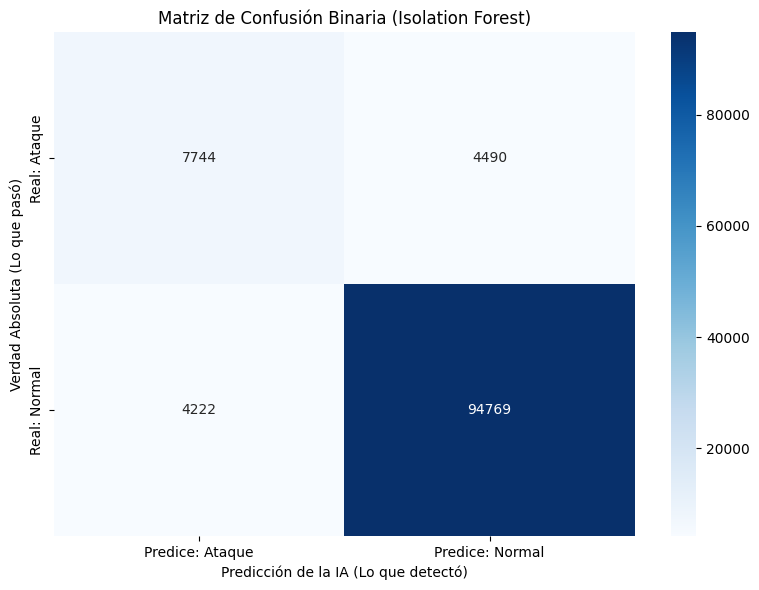


=== REPORTE DE CLASIFICACIÓN DE ATAQUES (RANDOM FOREST) ===
              precision    recall  f1-score   support

       Flood       0.84      0.55      0.67      7344
   LagSwitch       0.73      0.14      0.23      4890
     ninguno       0.93      0.99      0.96     98991

    accuracy                           0.92    111225
   macro avg       0.83      0.56      0.62    111225
weighted avg       0.91      0.92      0.91    111225

   [OK] Gráfica guardada como 'matriz_confusion_multiclase.png'


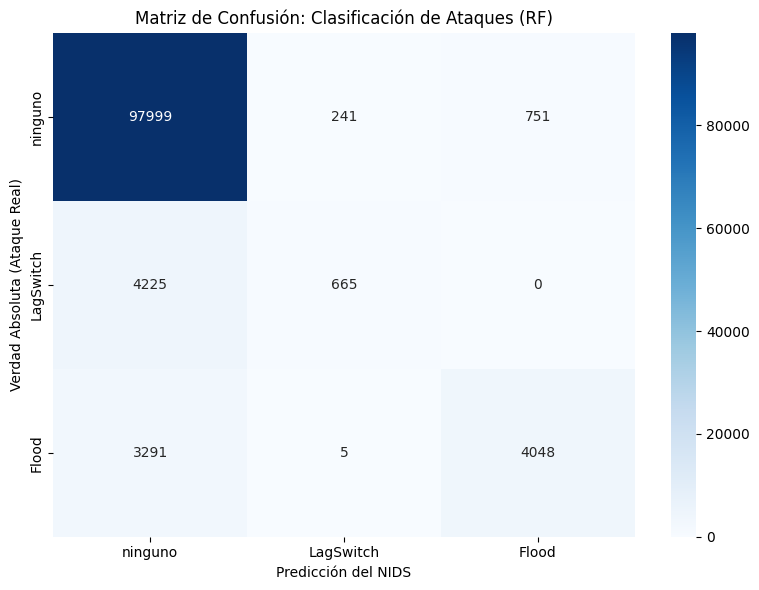


[VISUALIZACIÓN] Generando importancia de características...
   [OK] Gráfica guardada como 'feature_importance_rf.png'


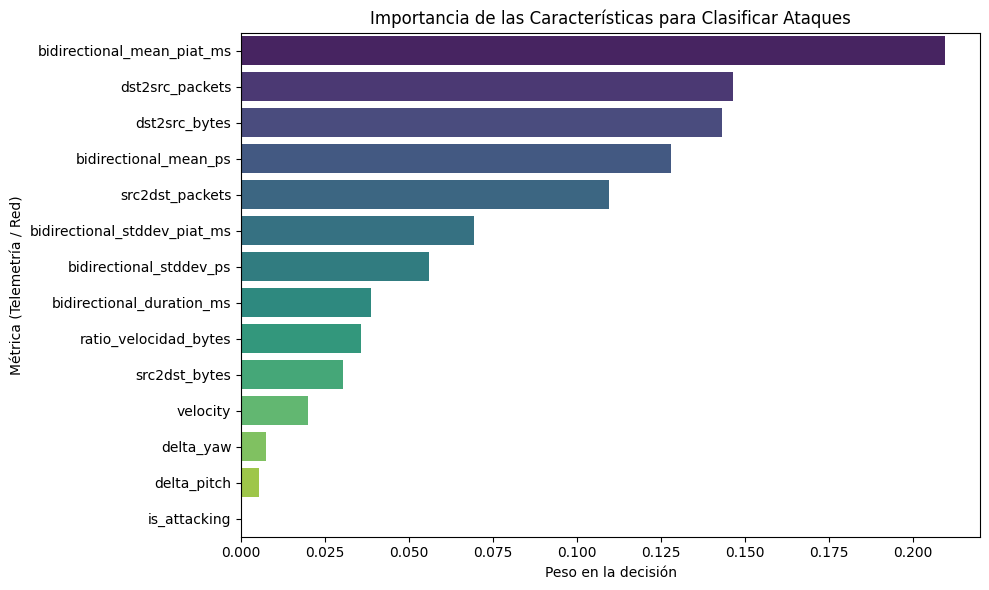


   MÉTRICA AVANZADA: DETECCIÓN POR EVENTOS
Total de inyecciones de trampa (Eventos reales): 17
Trampas detectadas por el IF (al menos 1 vez):   16
Tasa de Éxito Real del Anti-Cheat:               94.12%

[VISUALIZACIÓN] Generando gráfico de línea de tiempo de anomalías...
   [OK] Imagen guardada en tu entorno como 'timeline_ataques_real_separado.png'


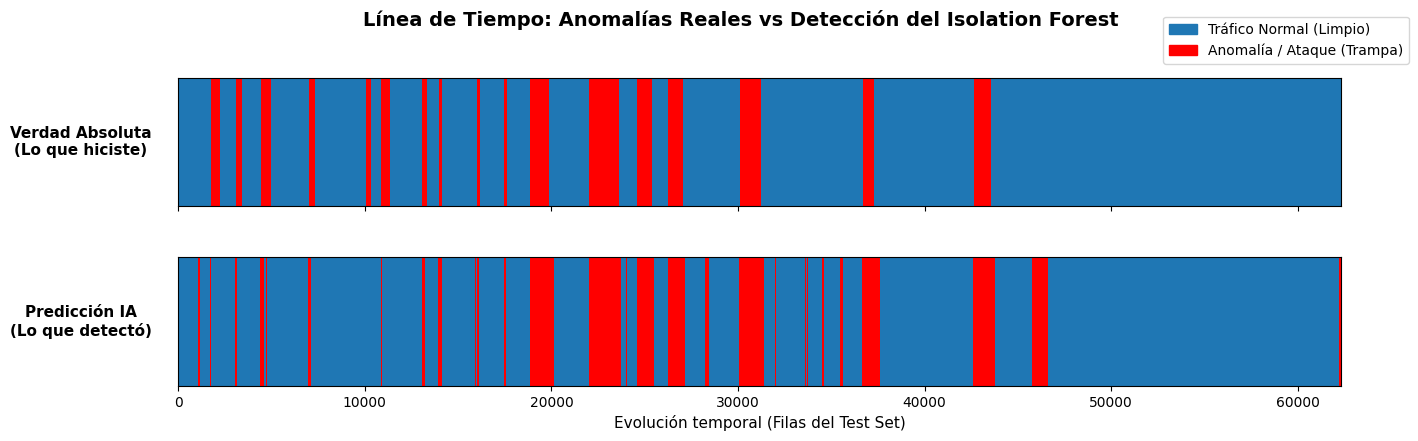



✅ ¡PROCESO FINALIZADO CON ÉXITO!


In [ ]:
# ===================================================================
# CELDA 8: EJECUCIÓN DEL PROCESO COMPLETO
# ===================================================================
lista_datasets = []
all_files_exist = True

# Verificación inicial de archivos
if not os.path.exists(ARCHIVO_SYNC_GLOBAL):
    print(f"[ERROR CRÍTICO] No se encuentra el archivo de tiempos '{ARCHIVO_SYNC_GLOBAL}'. Súbelo a Colab.")
    all_files_exist = False
else:
    for sesion in sesiones_a_procesar:
        for key in ["csv", "pcap_local", "pcap_amigo"]:
            if not os.path.exists(sesion[key]):
                print(f"[ERROR] Falta el archivo '{sesion[key]}' para la sesión. Súbelo a Colab.")
                all_files_exist = False

# Solo si todos los archivos existen, procedemos.
if all_files_exist:
    try:
        # 1. Procesamiento masivo
        for i, sesion in enumerate(sesiones_a_procesar, 1):
            print(f"\n====== PROCESANDO SESIÓN {i}/{len(sesiones_a_procesar)}: {sesion['csv']} ======")
            desfase = obtener_desfase_por_csv(ARCHIVO_SYNC_GLOBAL, sesion['csv'])
            
            df_sesion = preprocesar_y_fusionar(
                sesion['csv'], sesion['pcap_local'], sesion['pcap_amigo'], 
                desfase, sesion['id_host'], sesion['id_amigo'],
                sesion['tipo_red'], sesion['es_ataque'], sesion['fase'],
                sesion.get('tipo_ataque', 'ninguno')
            )
            lista_datasets.append(df_sesion)
            
        if not lista_datasets:
            raise ValueError("Ninguna sesión pudo ser procesada. Revisa los nombres de tus archivos y los IDs de jugador.")

        print("\n=> Uniendo todas las sesiones en un Dataset Maestro...")
        dataset_maestro = pd.concat(lista_datasets, ignore_index=True)
        
        # 2. Entrenamiento y Predicción Híbrida (IF + RF)
        # Aquí actualizamos los retornos y el nombre de la función
        modelo_if, modelo_rf, dataset_final, features, scaler = entrenar_nids(dataset_maestro)
        
        # 3. Volcado de datos para análisis posterior
        nombre_salida = "dataset_global_evaluado.csv"
        dataset_final.to_csv(nombre_salida, index=False)
        print(f"\n=> [OK] Dataset final con predicciones exportado a '{nombre_salida}'")
        
        # 4. Evaluación Científica Completa
        # Pasamos el modelo RF y las features a la función de evaluación
        evaluar_rendimiento(dataset_final, modelo_rf, features)
        
        print("\n\n¡PROCESO FINALIZADO CON ÉXITO!")
        
    except Exception as e:
        print(f"\n[ERROR FATAL] La ejecución se detuvo: {e}")